# NeuralForecast Experiments

Neural baselines. Pure sequence models use `runner_no_exog`; exogenous models use `runner_futr_exog`.

In [1]:
import importlib

import config as shared_config
import experiment
import experiment.config
import experiment.data
import experiment.rolling_forecast.artifacts
import experiment.rolling_forecast.executors
import experiment.rolling_forecast.executors.mlforecast
import experiment.rolling_forecast.executors.neural
import experiment.rolling_forecast.runner
import experiment.rolling_forecast.runtime

importlib.reload(shared_config)
importlib.reload(experiment.config)
importlib.reload(experiment.data)
importlib.reload(experiment.rolling_forecast.artifacts)
importlib.reload(experiment.rolling_forecast.executors.mlforecast)
importlib.reload(experiment.rolling_forecast.executors.neural)
importlib.reload(experiment.rolling_forecast.executors)
importlib.reload(experiment.rolling_forecast.runtime)
importlib.reload(experiment.rolling_forecast.runner)
importlib.reload(experiment)

from experiment import DatasetBuilder, ModelSpec, RollingForecastRunner, RunConfig

In [2]:
prepared_dataset = DatasetBuilder.from_csv(
    csv_path=shared_config.CSV_PATH,
    unique_id=shared_config.UNIQUE_ID,
    remove_last_month=shared_config.REMOVE_LAST_MONTH,
    hist_exog=shared_config.HIST_EXOG_LIST,
    futr_exog=shared_config.FUTR_EXOG_LIST,
)


def build_run_config(*, use_hist_exog: bool, use_futr_exog: bool) -> RunConfig:
    return RunConfig(
        input_size=shared_config.INPUT_SIZE,
        horizon=shared_config.HORIZON,
        split_ratio=shared_config.SPLIT_RATIO,
        sliding_step_size=shared_config.SLIDING_STEP_SIZE,
        use_hist_exog=use_hist_exog,
        use_futr_exog=use_futr_exog,
        save_plots=shared_config.SAVE_PLOTS,
        random_seed=shared_config.RANDOM_SEED,
        early_stop_patience_epochs=shared_config.EARLY_STOP_PATIENCE_EPOCHS,
        ml_early_stopping_rounds=shared_config.ML_EARLY_STOPPING_ROUNDS,
        neural_loss_name=shared_config.NEURAL_LOSS_NAME,
        neural_loss_params=shared_config.NEURAL_LOSS_PARAMS,
        neural_checkpoint_mode=shared_config.CHECKPOINT_MODE,
        save_dir=shared_config.SAVE_DIR,
        plot_forecast=shared_config.PLOT_FORECAST,
        plot_loss=shared_config.PLOT_LOSS,
        plot_loss_name=shared_config.PLOT_LOSS_NAME,
        freq=shared_config.FREQ,
    )

NEURAL_MAX_EPOCHS = 100
NEURAL_LEARNING_RATE = 1e-3

run_config_no_exog = build_run_config(
    use_hist_exog=False,
    use_futr_exog=False,
)
run_config_hist_exog = build_run_config(
    use_hist_exog=True,
    use_futr_exog=False,
)
run_config_futr_exog = build_run_config(
    use_hist_exog=False,
    use_futr_exog=True,
)
run_config_both_exog = build_run_config(
    use_hist_exog=True,
    use_futr_exog=True,
)

runner_no_exog = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config_no_exog,
)
runner_hist_exog = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config_hist_exog,
)
runner_futr_exog = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config_futr_exog,
)
runner_both_exog = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config_both_exog,
)


def run_model(model_spec: ModelSpec, runner: RollingForecastRunner):
    result = runner.run(model_spec)
    print(result.summary())
    print(f"rolling_raw_path: {result.rolling_raw_path}")
    return result

In [3]:
# from neuralforecast.models import NLinear

# nlinear_spec = ModelSpec(
#     name="NLinear",
#     model_type="neural",
#     model_cls=NLinear,
#     model_params={
#         "max_epochs": NEURAL_MAX_EPOCHS,
#         "learning_rate": NEURAL_LEARNING_RATE,
#     },
#     supports_hist_exog=False,
#     supports_future_exog=False,
# )

# nlinear_result = run_model(nlinear_spec, runner_no_exog)

In [4]:
# from neuralforecast.models import DLinear

# dlinear_spec = ModelSpec(
#     name="DLinear",
#     model_type="neural",
#     model_cls=DLinear,
#     model_params={
#         "moving_avg_window": 7,
#         "max_epochs": NEURAL_MAX_EPOCHS,
#         "learning_rate": NEURAL_LEARNING_RATE,
#     },
#     supports_hist_exog=False,
#     supports_future_exog=False,
# )

# dlinear_result = run_model(dlinear_spec, runner_no_exog)

Seed set to 2026


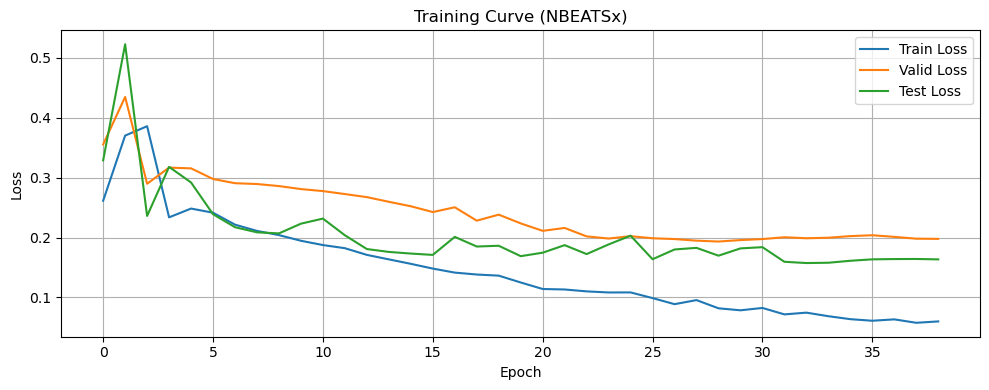

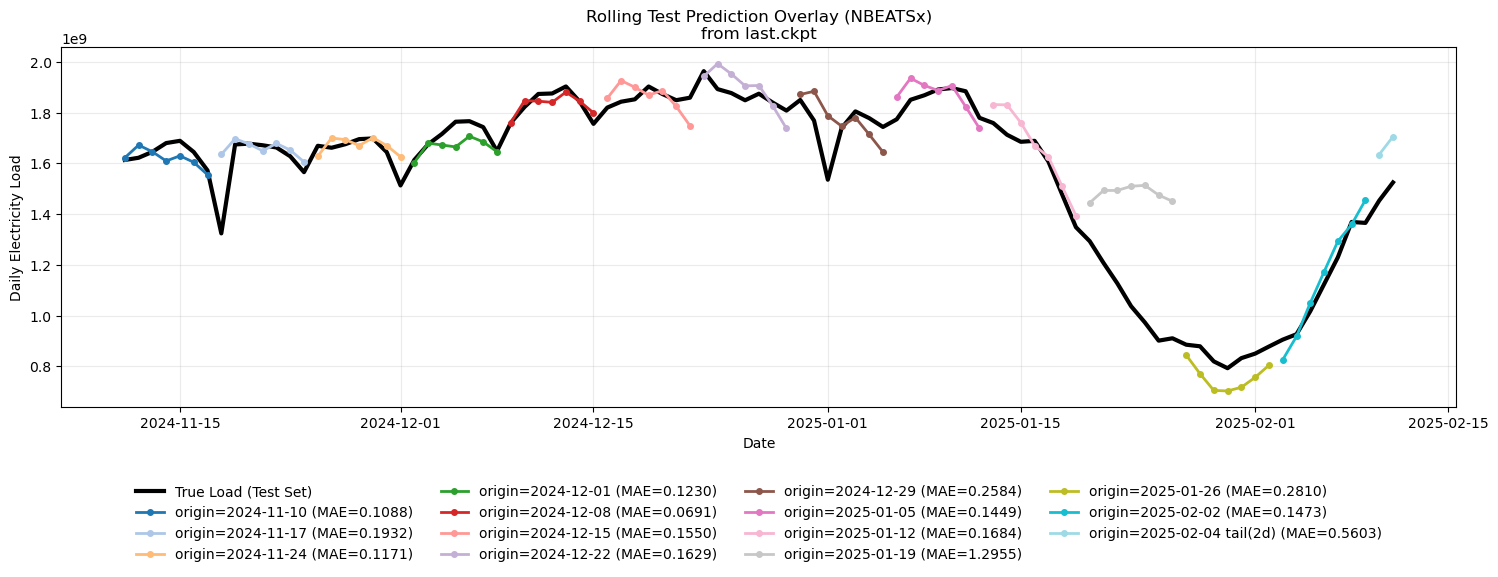

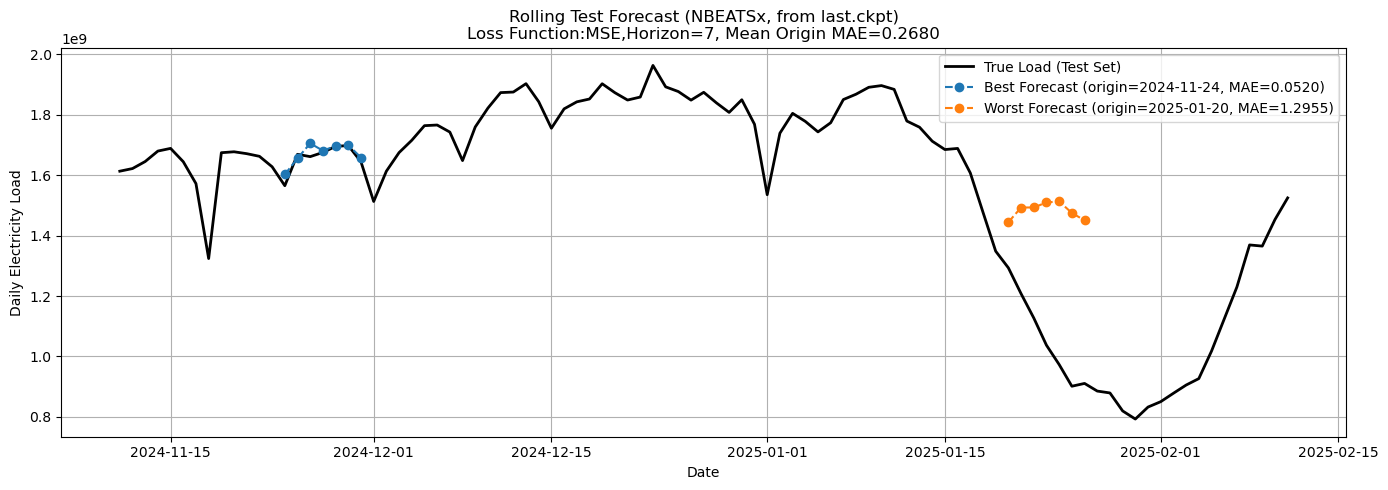

{'model_name': 'NBEATSx', 'val_overall_mape': 6.632009866741352, 'overall_mape': 6.4961116772110445, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\NBEATSx_futr_feat\\20260422_001226', 'best_model_path': 'artifacts\\NBEATSx_futr_feat\\20260422_001226\\checkpoints\\last.ckpt', 'val_best_model_path': 'artifacts\\NBEATSx_futr_feat\\20260422_001226\\checkpoints\\val_best.ckpt', 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\NBEATSx_futr_feat\\20260422_001226\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\NBEATSx_futr_feat\\20260422_001226\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\NBEATSx_futr_feat\20260422_001226\rolling_test_raw.csv


In [5]:
from neuralforecast.models import NBEATSx

nbeatsx_spec = ModelSpec(
    name="NBEATSx",
    model_type="neural",
    model_cls=NBEATSx,
    model_params={
        "max_epochs": NEURAL_MAX_EPOCHS,
        "learning_rate": NEURAL_LEARNING_RATE,
    },
    supports_hist_exog=True,
    supports_future_exog=True,
)

# nbeatsx_no_result = run_model(nbeatsx_spec, runner_no_exog)
# nbeatsx_hist_result = run_model(nbeatsx_spec, runner_hist_exog)
nbeatsx_futr_result = run_model(nbeatsx_spec, runner_futr_exog)
# nbeatsx_both_result = run_model(nbeatsx_spec, runner_both_exog)

Seed set to 2026


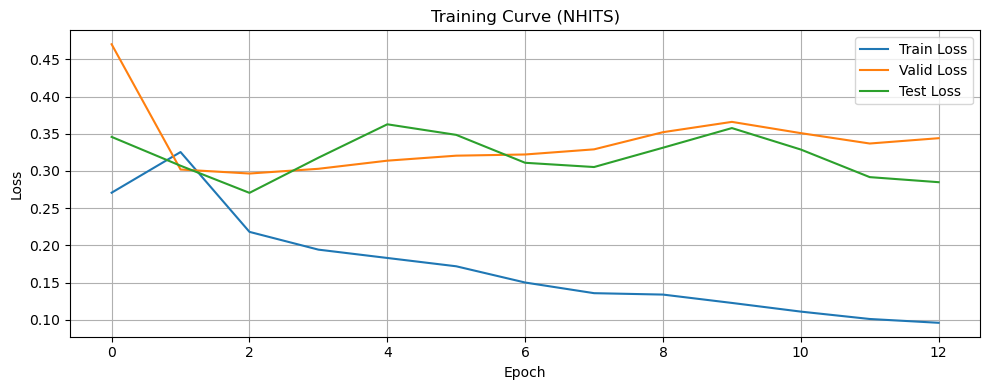

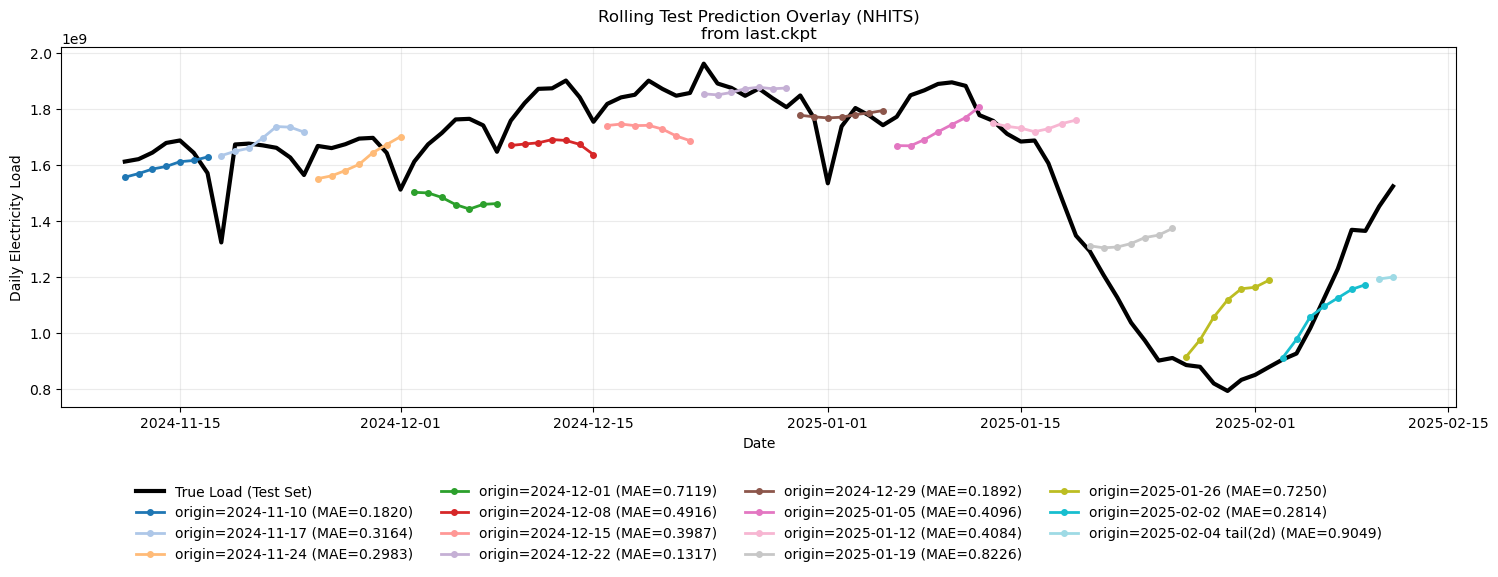

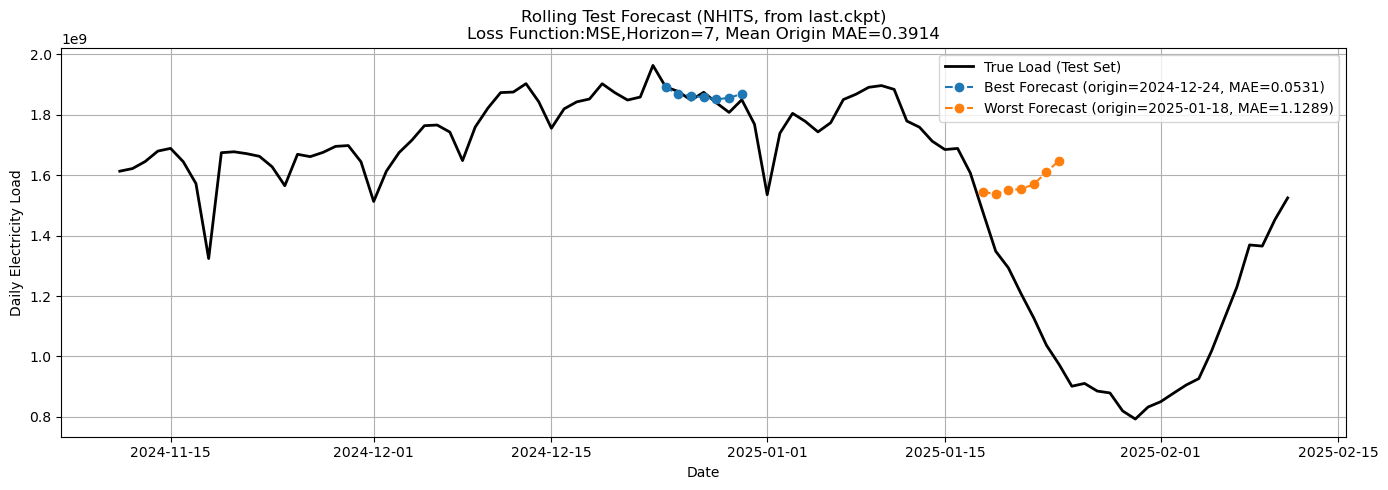

{'model_name': 'NHITS', 'val_overall_mape': 7.763279662762003, 'overall_mape': 9.74301678891047, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\NHITS_hist_feat\\20260422_172527', 'best_model_path': 'artifacts\\NHITS_hist_feat\\20260422_172527\\checkpoints\\last.ckpt', 'val_best_model_path': 'artifacts\\NHITS_hist_feat\\20260422_172527\\checkpoints\\val_best.ckpt', 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\NHITS_hist_feat\\20260422_172527\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\NHITS_hist_feat\\20260422_172527\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\NHITS_hist_feat\20260422_172527\rolling_test_raw.csv


In [ ]:
from neuralforecast.models import NHITS

nhits_spec = ModelSpec(
    name="NHITS",
    model_type="neural",
    model_cls=NHITS,
    model_params={
        "max_epochs": NEURAL_MAX_EPOCHS,
        "learning_rate": NEURAL_LEARNING_RATE,
    },
    supports_hist_exog=True,
    supports_future_exog=True,
)

# nhits_no_result = run_model(nhits_spec, runner_no_exog)
# nhits_hist_result = run_model(nhits_spec, runner_hist_exog)
nhits_futr_result = run_model(nhits_spec, runner_futr_exog)
# nhits_both_result = run_model(nhits_spec, runner_both_exog)

In [7]:
# from neuralforecast.models import PatchTST

# patchtst_spec = ModelSpec(
#     name="PatchTST",
#     model_type="neural",
#     model_cls=PatchTST,
#     model_params={
#         "n_heads": 4,
#         "hidden_size": 128,
#         "dropout": 0.1,
#         "max_epochs": NEURAL_MAX_EPOCHS,
#         "learning_rate": NEURAL_LEARNING_RATE,
#     },
#     supports_hist_exog=False,
#     supports_future_exog=False,
# )

# patchtst_result = run_model(patchtst_spec, runner_no_exog)

In [8]:
# from neuralforecast.models import TiDE

# tide_spec = ModelSpec(
#     name="TiDE",
#     model_type="neural",
#     model_cls=TiDE,
#     model_params={
#         "hidden_size": 128,
#         "decoder_output_dim": 16,
#         "temporal_decoder_dim": 64,
#         "dropout": 0.1,
#         "max_epochs": NEURAL_MAX_EPOCHS,
#         "learning_rate": NEURAL_LEARNING_RATE,
#     },
#     supports_hist_exog=True,
#     supports_future_exog=True,
# )

# tide_result = run_model(tide_spec, runner_futr_exog)

In [9]:
# from neuralforecast.models import TCN

# tcn_spec = ModelSpec(
#     name="TCN",
#     model_type="neural",
#     model_cls=TCN,
#     model_params={
#         "kernel_size": 2,
#         "dilations": [1, 2, 4, 8],
#         "encoder_hidden_size": 64,
#         "decoder_hidden_size": 64,
#         "decoder_layers": 2,
#         "max_epochs": NEURAL_MAX_EPOCHS,
#         "learning_rate": NEURAL_LEARNING_RATE,
#     },
#     supports_hist_exog=True,
#     supports_future_exog=True,
# )

# tcn_result = run_model(tcn_spec, runner_futr_exog)